# Genetic algorithm

Run a genetic algorithm (using DEAP) to derive stroke admission coefficients. This notebook just runs the optimisations. The results are checked in the next notebook.


Use variations of the coefficients derived from the SSNAP data (without deprivation information) as input,
and allow a different coefficient for each age band and each deprivation quantile.

Find the set of coefficients that...
+ ... minimises the sum of square residuals between the predicted and observed admissions across each MSOA...
+ ... while minimising error in each age band's predicted and observed admissions across all of England...
+ ... and while following the constraints that the coefficients should increase with age band and should increase with deprivation.

__Inputs:__
+ MSOA-level admissions numbers, numbers of people in each age band, and deprivation quantile.
+ SSNAP-derived stroke admission coefficients (probability of stroke given age band).
+ Admission numbers in England by age band.

__Results:__

+ From each run of the genetic algorithm, the population for the first generation, every tenth generation, and the final generation. Also a text log of the progress with each generation.


__Method:__

Use the SSNAP coefficients to derive starting points for the genetic algorithm:
  + Allow the set of coefficients for each deprivation band to equal the SSNAP coefficients multiplied by any scale factor in the range 0.2 to 2.0 inclusive in steps of 0.2.
  + Then allow any combination of sets for the five deprivation quantiles where the scale factor increases or remains constant with increasing deprivation.
  + There are 2002 starting combinations of scale factors.

The genetic algorithm forces the coefficients to meet the increase requirements: coefficients (*not* scale factors) must increase or remain constant with age band and with deprivation level.

_Generation:_ The genetic algorithm starts with 300 sets of coefficients picked from those 2002 sets with replacement (i.e. the same set could be picked more than once).

_Crossover:_ `cxTwoPoint` In each generation, each pair of individuals has an 80% chance of mating. This causes a subset of the coefficients with start and end points picked at random to be swapped between the two individuals.

_Mutation:_ `mutGaussian, mu=0.0, sigma=0.10` Each individual then has a 95% of mutation, but each coefficient has a much lower chance of individual mutation of 4% (1/25). This means that on average individuals that mutate should see only one of their 25 coefficients change.

_Selection:_ `selTournament, tournsize=3`

_Fitness:_ The goodness of fit of a set of coefficients is calculated by:
  + using the MSOA-level population by age band to calulate admission numbers by MSOA, using the matching coefficients for the MSOA's deprivation level.
  + calculating the sum of square residuals of calculated and observed admission numbers across all MSOA.
  + summing the admission numbers for each age band across all MSOA. The sum of absolute differences of the ratio of the calculated and observed admission numbers from exactly 1 (i.e. no difference in calculated and observed numbers) for all five age bands is used as a "wrongness factor". The sum of square residuals is multiplied by this factor.
  + lower scores are better (less difference in observed and predicted admissions after penalty).

The algorithm runs for either 1000 generations or when there is very little variation in the coefficients of the population (standard deviation of values for each coeff is less than 5% of their mean for all coeffs), whichever happens sooner.


In [1]:
import deap

In [2]:
import random

from deap import base
from deap import creator
from deap import tools

In [3]:
import numpy as np
import os
import polars as pl
import matplotlib.pyplot as plt

In [4]:
from itertools import product

## Load admissions data

In [5]:
path_to_msoa_stats = os.path.join('data', 'msoa_cleaned.csv')

df_stats = pl.read_csv(path_to_msoa_stats)

In [6]:
df_stats.head()

MSOA,admissions,IMD2019Score,All persons,country,good_health,fair health,bad health,prop_good_health,prop_fair health,prop_bad health,MSOA11CD,age_65_proportion,age_70_proportion,age_75_proportion,age_less65_proportion,age_over80_proportion,total_health,age_less65,age_65,age_70,age_75,age_over80,depriv_quantile_min,depriv_quantile_max
str,f64,f64,i64,str,i64,i64,i64,f64,f64,f64,str,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64
"""Adur 001""",14.333333,16.924833,8815,"""E""",6799,1251,474,0.79763,0.146762,0.055608,"""E02006534""",0.0559,0.0528,0.0422,0.7872,0.062,8524,6939.168,492.7585,465.432,371.993,546.53,0.4,0.6
"""Adur 002""",7.333333,6.4704,7263,"""E""",5537,838,259,0.83464,0.126319,0.039041,"""E02006535""",0.0578,0.0774,0.0492,0.7467,0.0692,6634,5423.2821,419.8014,562.1562,357.3396,502.5996,0.8,1.0
"""Adur 003""",9.333333,13.7334,7354,"""E""",5820,969,311,0.819718,0.136479,0.043803,"""E02006536""",0.0609,0.0582,0.0421,0.7729,0.0661,7100,5683.9066,447.8586,428.0028,309.6034,486.0994,0.6,0.8
"""Adur 004""",21.0,26.199857,10582,"""E""",7872,1546,709,0.777328,0.152661,0.070011,"""E02006537""",0.0465,0.0438,0.0367,0.8091,0.0638,10127,8561.8962,492.063,463.4916,388.3594,675.1316,0.2,0.4
"""Adur 005""",13.666667,11.7948,9059,"""E""",7106,1081,339,0.833451,0.126789,0.039761,"""E02006538""",0.0597,0.067,0.0425,0.7643,0.0662,8526,6923.7937,540.8223,606.953,385.0075,599.7058,0.6,0.8


Pick out column names for the health and age proportions:

In [7]:
health_numbers = ['good_health', 'fair health', 'bad health']
props_health = ['prop_good_health', 'prop_fair health', 'prop_bad health']
props_age = [
    'age_less65_proportion', 'age_65_proportion', 'age_70_proportion',
    'age_75_proportion', 'age_over80_proportion'
]
age_numbers = [p.replace('_proportion', '') for p in props_age]

In [8]:
qmin_list = sorted(df_stats['depriv_quantile_min'].unique())

SSNAP coefficients and population data:

In [9]:
df_pop_admissions = pl.read_csv(os.path.join('outputs', 'ssnap_coeffs.csv'))

In [10]:
df_pop_admissions

Age Groups,population,prop_of_all_pop,count,prop_of_all_admissions,admissions_annual,admissions_annual_boost,prob_stroke_given_age
str,i64,f64,i64,f64,f64,f64,f64
"""Under 65""",45933245,0.816055,38827,0.231449,12942.33333,18737.66819,0.000408
"""65-69""",2796740,0.049687,15324,0.091347,5108.0,7395.26689,0.002644
"""70-74""",2779326,0.049378,21508,0.12821,7169.33333,10379.62674,0.003735
"""75-79""",1940686,0.034478,24150,0.143959,8050.0,11654.63948,0.006005
"""80 and over""",2836964,0.050402,67947,0.405035,22649.0,32790.7987,0.011558


Pick out SSNAP coefficients:

In [11]:
coeffs_ssnap = df_pop_admissions['prob_stroke_given_age'].to_numpy()

coeffs_ssnap

array([0.000408, 0.002644, 0.003735, 0.006005, 0.011558])

Pick out admissions numbers:

In [12]:
dict_admissions_age = dict(zip(df_pop_admissions['Age Groups'], df_pop_admissions['admissions_annual_boost']))

admissions_by_age = list(dict_admissions_age.values())

dict_admissions_age

{'Under 65': 18737.66819,
 '65-69': 7395.26689,
 '70-74': 10379.62674,
 '75-79': 11654.63948,
 '80 and over': 32790.7987}

## Parameter setup

Which values are allowed for each coefficient?

In [13]:
df_coeffs_init = pl.read_csv(os.path.join('outputs', 'multi_deap_coeffs_init.csv'))

Only keep coeff combos with a good enough fitness score:

In [14]:
mask = df_coeffs_init['fitness'] <= (df_coeffs_init['fitness'].min() * 2.0)


print(len(df_coeffs_init))
df_coeffs_init = df_coeffs_init.filter(mask)
print(len(df_coeffs_init))

2659
886


Only keep columns with coefficient values:

In [15]:
coeff_names = [c for c in df_coeffs_init.columns if c.startswith('age')]

df_coeffs_init = df_coeffs_init[['coeff_combo'] + coeff_names]

In [16]:
df_coeffs_init.min()

coeff_combo,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
8,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.6,0.6,0.6,0.6,0.6,0.3,0.3,0.3,0.3,0.3


In [17]:
df_coeffs_init.max()

coeff_combo,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2405,2.0,2.0,2.0,2.0,2.0,1.6,1.6,1.6,1.6,1.6,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## Admissions prediction setup

In [18]:
def predict_admissions(x_lists, coeffs):
    """
    x_lists: np.array.
    coeffs: np.array.
    
    Have to have same number of coeffs as x_lists.
    """
    # Predicted admissions:
    # yhat = (x_lists * coeffs.reshape(len(coeffs), 1)).sum(axis=0)
    yhat = sum(
        [x_lists[i] * coeffs[i] for i in range(len(coeffs))]
    )
    return yhat.to_numpy().tolist()

In [19]:
def predict_admissions_each_age(x_lists, coeffs):
    """
    x_lists: np.array.
    coeffs: np.array.
    
    Have to have same number of coeffs as x_lists.
    """
    # Predicted admissions:
    yhat = (
        [(x_lists[i] * coeffs[i]).sum() for i in range(len(coeffs))]
    )
    return yhat

Goodness check option 1: This calculates the sum of the square of the differences between predicted and actual admission numbers:

In [21]:
def find_square_residuals(yhat, y):
    # Difference from actual:
    sqres = (np.array(yhat) - np.array(y))**2.0
    # Sum of differences:
    sum_sqres = sqres.sum()
    return np.sqrt(sum_sqres)

Goodness check option 2: This calculates the mean absolute difference between the predicted and real admissions numbers:

In [22]:
# def find_mean_abs_diff(yhat, y):
#     # Difference from actual:
#     absres = np.abs((yhat - y))
#     # Mean of differences:
#     mean_absres = absres.mean()
#     return mean_absres

Goodness check option 3: This calculates the sum of the ratio of the error to each observed number of strokes:

In [20]:
# def find_err_ratios(yhat, y):
#     # Difference from actual:
#     sqres = np.abs(np.array(yhat) - np.array(y)) / np.array(y)
#     # Sum of differences:
#     sum_sqres = sqres.sum()
#     return sum_sqres

To check accuracy, the following function calculates R-squared:

In [23]:
def calculate_rsquared(y, yhat):
    """This gives the same results as the sklearn built-in."""
    y = np.array(y)
    yhat = np.array(yhat)
    y_mean = np.mean(y)#.mean()
    ss_res = np.sum(((yhat - y)**2.0))#.sum()
    ss_tot = np.sum(((y - y_mean)**2.0))#.sum()
    if ss_tot != 0.0:
        rsq = 1.0 - ss_res / ss_tot
    else:
        rsq = np.NaN
    return rsq

## Define functions for algorithm

The following functions will be fed into the genetic algorithm object.

In [24]:
def gen_attr(df):
    """
    Pick out a set of coefficients from the dataframe.
    """
    row_index = random.randrange(0, len(df), 1)
    new_coeffs = df[row_index, :][coeff_names].to_numpy().tolist()[0]
    new_coeffs = force_coeffs_increasing(coeffs_ssnap, new_coeffs)
    new_coeffs = round_coeffs(new_coeffs)
    return tuple(new_coeffs)

In [25]:
def round_coeffs(coeffs):
    return tuple([round(c, 3) for c in coeffs])

In [26]:
def clip_coeffs(coeffs):
    # Clip coefficients to sit within allowed range.
    return np.clip(coeffs, a_min=0.0, a_max=10.0,).tolist()

In [27]:
def force_coeffs_increasing(coeffs_ssnap, coeffs):
    """
    Make sure each coefficient is no larger than the next.
    """
    def check_success(coeffs_grid, coeffs_ssnap):
        # # Check difference along each row:
        # q_ok = (np.sign(np.diff(coeffs_grid, axis=1)) >= 0).all()
        # # Check difference along each column:
        # age_ok = (np.sign(np.diff(coeffs_grid, axis=0)) >= 0).all()
        signs_age, signs_q = check_pattern(coeffs_grid, coeffs_ssnap)
        age_ok = (signs_age == 0).all()
        q_ok = (signs_q == 0).all()
        return (q_ok & age_ok)
    
    def check_pattern(coeffs_grid, coeffs_ssnap):
        # Start with a 5x5 grid:
        signs_age = np.zeros((5, 5), dtype=int)
        signs_q = np.zeros((5, 5), dtype=int)
        # Fill in all but the first row/column with diffs:
        signs_age[1:, :] = (np.sign(np.diff(coeffs_grid * coeffs_ssnap, axis=0)) > 0).astype(int)
        signs_q[:, :-1] = (np.sign(np.diff(coeffs_grid * coeffs_ssnap, axis=1)) < 0).astype(int)
        return signs_age, signs_q
    
    def sort_inds_by_farthest(inds):
        if len(inds[0]) < 2:
            # Don't bother if there's nothing to sort.
            return inds
        else:
            pass

        # Gather rows and columns into one array:
        inds_stack = np.vstack(inds)
        # Find the largest row/column:
        max_ind = np.max(inds_stack, axis=0)
        # Find the order that would sort them from largest to smallest:
        inds_sort = np.argsort(max_ind)[::-1]
        # Sort the inds:
        inds = (inds[0][inds_sort], inds[1][inds_sort])
        return inds
        
    coeffs_grid = np.array(coeffs).reshape(5, 5)
    success = check_success(coeffs_grid, coeffs_ssnap)

    count = 0
    while success == False:
        signs_age, signs_q = check_pattern(coeffs_grid, coeffs_ssnap)
        # Pick out which values don't fit the pattern.
        # Each inds tuple has an array of the row indices, inds[0],
        # and then an array of the column indices, inds[1].
        inds_to_change_age = np.where(signs_age > 0)
        inds_to_change_q = np.where(signs_q > 0)
        inds_to_change_both = np.where((signs_q > 0) & (signs_age > 0))
        # Order the inds, farthest row/column first:
        inds_to_change_age = sort_inds_by_farthest(inds_to_change_age)
        inds_to_change_q = sort_inds_by_farthest(inds_to_change_q)
        inds_to_change_both = sort_inds_by_farthest(inds_to_change_both)

        # Nudge the values, starting from the far edges.
        if len(inds_to_change_both[0]) > 0:
            # Set the breaking value to whichever is smaller of its
            # adjacent coefficients.
            ind_row = inds_to_change_both[0][0]
            ind_col = inds_to_change_both[1][0]
            # Pick out the next values along:
            next_age = coeffs_grid[ind_row - 1, ind_col] * coeffs_ssnap[ind_col]
            next_q = coeffs_grid[ind_row, ind_col + 1] * coeffs_ssnap[ind_col + 1]
            # Find the smaller one:
            new_val = np.min([next_q, next_age])
            # Update the coefficient:
            coeffs_grid[ind_row, ind_col] = new_val / coeffs_ssnap[ind_col]
        elif len(inds_to_change_age[0]) > 0:
            # Set the breaking value to the next age up.
            ind_row = inds_to_change_age[0][0]
            ind_col = inds_to_change_age[1][0]
            # Pick out the next value along:
            new_val = coeffs_grid[ind_row - 1, ind_col] * coeffs_ssnap[ind_col]
            # Update the coefficient:
            coeffs_grid[ind_row, ind_col] = new_val / coeffs_ssnap[ind_col]
        else:
            # Set the breaking value to the next q up.
            ind_row = inds_to_change_q[0][0]
            ind_col = inds_to_change_q[1][0]
            # Pick out the next value along:
            new_val = coeffs_grid[ind_row, ind_col + 1] * coeffs_ssnap[ind_col + 1]
            # Update the coefficient:
            coeffs_grid[ind_row, ind_col] = new_val / coeffs_ssnap[ind_col]

        success = check_success(coeffs_grid, coeffs_ssnap)
        count += 1
        if count > 100:
            # Give up.
            success = True
    
    return coeffs_grid.flatten().tolist()

Evaluate over all q bands at once.

In [28]:
# the goal ('fitness') function to be maximized
def eval_admissions(coeffs_ssnap, admissions_lists, x_lists, admissions_by_age, individual):

    # Predictions for each age band across England:
    predictions_by_age = [0.0] * 5
    for i in range(5):
        # Population numbers for areas in this quantile:
        x_lists_here = x_lists[i]
        # Separate prediction for each deprivation quantile:
        coeffs = individual[(i*5):(i*5)+5] * np.array(coeffs_ssnap)
        yhat_list = predict_admissions_each_age(x_lists_here, coeffs)
        # predictions_lists.append(yhat)
        for j, y in enumerate(yhat_list):
            predictions_by_age[j] += y
    # Divide the admissions by age band by the observed values:
    for j in range(len(predictions_by_age)):
        predictions_by_age[j] /= admissions_by_age[j]
    # Wrongness ratio factor:
    rat = sum(np.abs(np.array(predictions_by_age) - 1.0)) + 1.0
    
    # Predictions for each MSOA:
    predictions_lists = []
    for i in range(5):
        # Population numbers for areas in this quantile:
        x_lists_here = x_lists[i]
        # Separate prediction for each deprivation quantile:
        coeffs = individual[(i*5):(i*5)+5] * np.array(coeffs_ssnap)
        yhat = predict_admissions(x_lists_here, coeffs)
        predictions_lists.append(yhat)

    # Combine lists:
    observed_all = sum(admissions_lists, [])
    predicted_all = sum(predictions_lists, [])
    # Use only one of the following options for checking the fit:
    sum_sqres = find_square_residuals(predicted_all, observed_all)
    # sum_sqres = find_err_ratios(predicted_all, observed_all)
    # sum_sqres = find_mean_abs_diff(yhat, admissions)

    # Apply wrongness factor:
    sum_sqres *= rat
    
    return sum_sqres,

Gather data for use with the evaluation function:

In [29]:
admissions_lists = []
x_lists = []

for qmin in qmin_list:
    df_stats_here = df_stats.filter(df_stats['depriv_quantile_min'] == qmin)
    # MSOA data in the same order as those coefficients:
    x_lists_here = [df_stats_here[a] for a in age_numbers]
    admissions_here = df_stats_here['admissions'].to_numpy().tolist()
    # Store:
    admissions_lists.append(admissions_here)
    x_lists.append(x_lists_here)

## Testing ground

Check the force-increasing function:

In [30]:
coeffs = np.vstack([np.arange(1.2, 0.7, -0.1)]*5).transpose().flatten()
print(np.array(coeffs).reshape(5, 5))
print(np.array(coeffs).reshape(5, 5) * coeffs_ssnap)

print(np.array(force_coeffs_increasing(coeffs_ssnap, coeffs)).reshape(5, 5) * coeffs_ssnap)
print(np.array(force_coeffs_increasing(coeffs_ssnap, coeffs)).reshape(5, 5))

force_coeffs_increasing(coeffs_ssnap, coeffs)

[[1.2 1.2 1.2 1.2 1.2]
 [1.1 1.1 1.1 1.1 1.1]
 [1.  1.  1.  1.  1. ]
 [0.9 0.9 0.9 0.9 0.9]
 [0.8 0.8 0.8 0.8 0.8]]
[[0.0004896 0.0031728 0.004482  0.007206  0.0138696]
 [0.0004488 0.0029084 0.0041085 0.0066055 0.0127138]
 [0.000408  0.002644  0.003735  0.006005  0.011558 ]
 [0.0003672 0.0023796 0.0033615 0.0054045 0.0104022]
 [0.0003264 0.0021152 0.002988  0.004804  0.0092464]]
[[0.0004896 0.0031728 0.004482  0.007206  0.0138696]
 [0.0004488 0.0029084 0.0041085 0.0066055 0.0127138]
 [0.000408  0.002644  0.003735  0.006005  0.011558 ]
 [0.0003672 0.0023796 0.0033615 0.0054045 0.0104022]
 [0.0003264 0.0021152 0.002988  0.004804  0.0092464]]
[[1.2 1.2 1.2 1.2 1.2]
 [1.1 1.1 1.1 1.1 1.1]
 [1.  1.  1.  1.  1. ]
 [0.9 0.9 0.9 0.9 0.9]
 [0.8 0.8 0.8 0.8 0.8]]


[1.2,
 1.2,
 1.2,
 1.2,
 1.2,
 1.0999999999999999,
 1.0999999999999999,
 1.0999999999999999,
 1.0999999999999999,
 1.0999999999999999,
 0.9999999999999998,
 0.9999999999999998,
 0.9999999999999998,
 0.9999999999999998,
 0.9999999999999998,
 0.8999999999999997,
 0.8999999999999997,
 0.8999999999999997,
 0.8999999999999997,
 0.8999999999999997,
 0.7999999999999996,
 0.7999999999999996,
 0.7999999999999996,
 0.7999999999999996,
 0.7999999999999996]

In [31]:
coeffs = np.vstack([np.arange(1.2, 0.7, -0.1)]*5).transpose().flatten()
coeffs[1] += 0.6
coeffs[11] += 0.6
coeffs[17] += 0.6

print(np.array(coeffs).reshape(5, 5))
print(np.array(force_coeffs_increasing(coeffs_ssnap, coeffs)).reshape(5, 5))


print(np.array(coeffs).reshape(5, 5) * coeffs_ssnap)
print(np.array(force_coeffs_increasing(coeffs_ssnap, coeffs)).reshape(5, 5) * coeffs_ssnap)

[[1.2 1.8 1.2 1.2 1.2]
 [1.1 1.1 1.1 1.1 1.1]
 [1.  1.6 1.  1.  1. ]
 [0.9 0.9 1.5 0.9 0.9]
 [0.8 0.8 0.8 0.8 0.8]]
[[1.2        1.69515885 1.2        1.2        1.2       ]
 [1.1        1.1        1.1        1.1        1.1       ]
 [1.         1.1        1.         1.         1.        ]
 [0.9        0.9        1.         0.9        0.9       ]
 [0.8        0.8        0.8        0.8        0.8       ]]
[[0.0004896 0.0047592 0.004482  0.007206  0.0138696]
 [0.0004488 0.0029084 0.0041085 0.0066055 0.0127138]
 [0.000408  0.0042304 0.003735  0.006005  0.011558 ]
 [0.0003672 0.0023796 0.0056025 0.0054045 0.0104022]
 [0.0003264 0.0021152 0.002988  0.004804  0.0092464]]
[[0.0004896 0.004482  0.004482  0.007206  0.0138696]
 [0.0004488 0.0029084 0.0041085 0.0066055 0.0127138]
 [0.000408  0.0029084 0.003735  0.006005  0.011558 ]
 [0.0003672 0.0023796 0.003735  0.0054045 0.0104022]
 [0.0003264 0.0021152 0.002988  0.004804  0.0092464]]


Example generate some coeffs:

In [32]:
np.array(gen_attr(df_coeffs_init)).reshape(5, 5)

array([[1.7, 1.7, 1.7, 1.7, 1.7],
       [1.3, 1.3, 1.3, 1.3, 1.3],
       [1. , 1. , 1. , 1. , 1. ],
       [0.8, 0.8, 0.8, 0.8, 0.8],
       [0.8, 0.8, 0.8, 0.8, 0.8]])

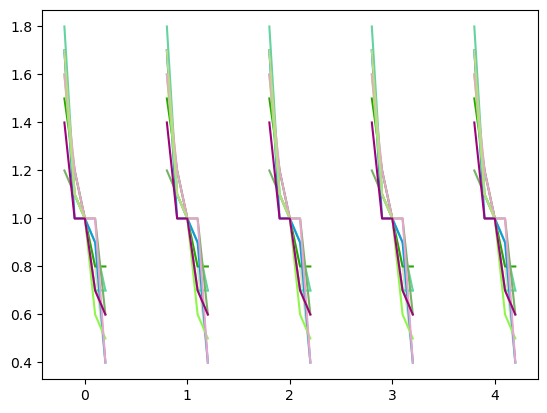

In [33]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()

for i in range(10):
    colour = np.random.rand(3,)
    g = gen_attr(df_coeffs_init)

    offset = -0.2
    for c in range(5):
        # xs = np.arange(5) + offset
        # ys = g[c*5:(c*5)+5]
        xs = np.arange(-0.2, 0.3, 0.1) + c
        
        ys = np.array(g)[np.arange(0, 25, 5) + c]
        ax.plot(xs, ys, color=colour)
        offset += 0.1
plt.show()

Evaluation function:

In [ ]:
eval_admissions(coeffs_ssnap, admissions_lists, x_lists, admissions_by_age, gen_attr(df_coeffs_init))

## Set up algorithm

Started with examples from the DEAP documentation: https://deap.readthedocs.io/en/master/

In [35]:
creator.create("FitnessMax", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

In [36]:
toolbox = base.Toolbox()

#----------
# Operator registration
#----------

# Population creation:
toolbox.register("gen_attr", gen_attr, df_coeffs_init)

toolbox.register("individual", tools.initIterate, creator.Individual, toolbox.gen_attr)

# define the population to be a list of individuals
# but don't specify how many here.
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# Individual changes:
# register the crossover operator
toolbox.register("mate", tools.cxTwoPoint)

# register a mutation operator with a probability to
# flip each attribute/gene of 0.04
toolbox.register("mutate", tools.mutGaussian, mu=0.0, sigma=0.10, indpb=0.04)  # approx 1 in 25 change of mutation

# operator for selecting individuals for breeding the next
# generation: each individual of the current generation
# is replaced by the 'fittest' (best) of three individuals
# drawn randomly from the current generation.
toolbox.register("select", tools.selTournament, tournsize=3)

# For this deprivation quantile, need to pass these admissions
# into the evaluation function:
# register the goal / fitness function
toolbox.register("evaluate", eval_admissions, coeffs_ssnap, admissions_lists, x_lists, admissions_by_age)

#----------
# Helper functions:
toolbox.register("clip", clip_coeffs)
toolbox.register("round", round_coeffs)
toolbox.register("force_increasing", force_coeffs_increasing, coeffs_ssnap)

## Run

Run for each IMD band separately.

In [37]:
def main(seed, output_dir='', start_gen=0, cancel_gen=1000):
    random.seed(seed)

    # create an initial population of 300 individuals (where
    # each individual is a list of integers)
    pop = toolbox.population(n=300)

    # CXPB  is the probability with which two individuals
    #       are crossed
    #
    # MUTPB is the probability for mutating an individual
    CXPB = 0.8
    MUTPB = 0.95

    # Keep a copy of the printed text:
    log = ''
    log += "Start of evolution\n"

    # Evaluate the entire population
    fitnesses = list(map(toolbox.evaluate, pop))
    for ind, fit in zip(pop, fitnesses):
        ind.fitness.values = fit

    log += f"  Evaluated {len(pop)} individuals\n"

    # Extracting all the fitnesses of 
    fits = [ind.fitness.values[0] for ind in pop]

    # Keep a copy of the best individual in each generation:
    best_inds = []
    
    # Variable keeping track of the number of generations
    g = start_gen

    # Begin the evolution
    carry_on_please = True
    while carry_on_please:
        # A new generation
        log += f'Seed {seed:02d} -- Generation {g} --\n'
        print(f'Seed {seed:02d} -- Generation {g} --', end='\r')
        # print(f'-- Generation {g} --')
        # print(pop)

        # Select the next generation individuals
        offspring = toolbox.select(pop, len(pop))

        if g == start_gen:
            # Save results.
            arr = np.array(pop)
            fits = [ind.fitness.values[0] for ind in pop]
            arr = np.hstack((arr, np.array(fits).reshape(len(fits), 1)))
            np.savetxt(
                os.path.join('genetic_algorithms', 'outputs', output_dir, f'gen{g:04d}_startpop.csv'),
                arr, fmt='%.6f', delimiter=',', header=','.join(coeff_names + ['fitness'])
            )
            best_ind = tools.selBest(pop, 1)[0]
            best_ind_str = ', '.join([f'{b:9.7f}' for b in best_ind])
            b = best_ind.fitness.values[0]
            log += f'Best starting individual is ({best_ind_str}), {b:.5f}\n'
    
            best_inds.append(best_ind)
            
        # Clone the selected individuals
        offspring = list(map(toolbox.clone, offspring))

        # Apply crossover and mutation on the offspring
        for child1, child2 in zip(offspring[::2], offspring[1::2]):

            # cross two individuals with probability CXPB
            if random.random() < CXPB:
                toolbox.mate(child1, child2)

                # fitness values of the children
                # must be recalculated later
                del child1.fitness.values
                del child2.fitness.values

        for mutant in offspring:
            # mutate an individual with probability MUTPB
            if random.random() < MUTPB:
                toolbox.mutate(mutant)
                del mutant.fitness.values

        # Evaluate the individuals with an invalid fitness
        invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
        
        # Clip values to fit within parameter bounds.
        for ind in invalid_ind:
            ind[:] = toolbox.clip(ind)
        # Round values.
        for ind in invalid_ind:
            ind[:] = toolbox.round(ind)
        # Force coefficients to increase with age band.
        for ind in invalid_ind:
            ind[:] = toolbox.force_increasing(ind)
        
        fitnesses = map(toolbox.evaluate, invalid_ind)
        for ind, fit in zip(invalid_ind, fitnesses):
            ind.fitness.values = fit

        log += f"  Evaluated {len(invalid_ind)} individuals\n"

        # The population is entirely replaced by the offspring
        pop[:] = offspring

        # Gather all the fitnesses in one list and print the stats
        fits = [ind.fitness.values[0] for ind in pop]

        length = len(pop)
        mean = sum(fits) / length
        sum2 = sum(x*x for x in fits)
        std = abs(sum2 / length - mean**2)**0.5

        log += f'  Min {min(fits):9.5f}\n'
        log += f'  Max {max(fits):9.5f}\n'
        log += f'  Avg {mean:9.5f}\n'
        log += f'  Std {std:9.5f}\n'
            
        best_ind = tools.selBest(pop, 1)[0]
        best_ind_str = ', '.join([f'{b:9.7f}' for b in best_ind])
        b = best_ind.fitness.values[0]
        log += f'Best individual is ({best_ind_str}), {b:.5f}\n'

        best_inds.append(best_ind)

        # Check continue condition
        c = np.array(pop).std(axis=0) / np.array(pop).mean(axis=0)
        if (c < 0.05).all():
            carry_on_please = False
            log += "-- End of (successful) evolution --\n"
        elif g > (cancel_gen - 1):
            carry_on_please = False
            log += "-- End of evolution --\n"
            log += "(cancelled after 1000 generations)\n"
        else:
            g = g + 1

        if (g % 10 == 0) | (carry_on_please == False):
            # Save results.
            arr = np.array(pop)
            fits = [ind.fitness.values[0] for ind in pop]
            arr = np.hstack((arr, np.array(fits).reshape(len(fits), 1)))
            np.savetxt(
                os.path.join('genetic_algorithms', 'outputs', output_dir, f'gen{g:04d}.csv'),
                arr, fmt='%.3f', delimiter=',', header=','.join(coeff_names + ['fitness'])
            )


    return pop, best_inds, log, g

Run the algorithm for 100 random seeds:

In [39]:
for seed in range(0, 100, 1):
    output_dir = f'randomseed{seed:02d}'
    if not os.path.exists(os.path.join('genetic_algorithms', 'outputs', output_dir)):
        os.mkdir(os.path.join('genetic_algorithms', 'outputs', output_dir))
        
    start_gen = 1
    pop_results, best_inds, log, end_gen = main(seed=seed, output_dir=output_dir, start_gen=start_gen, cancel_gen=1000)
    # Store a copy of the best results:
    with open(os.path.join('genetic_algorithms', 'outputs', output_dir, 'log.txt'), 'w') as text_file:
        text_file.write(log)
    
    arr = np.array(best_inds)
    fits = [ind.fitness.values[0] for ind in best_inds]
    gens = np.arange(start_gen-1, end_gen+1, 1)
    arr = np.hstack((gens.reshape(len(gens), 1), arr, np.array(fits).reshape(len(fits), 1)))
    np.savetxt(os.path.join('genetic_algorithms', 'outputs', output_dir, f'best_inds_by_gen.csv'), arr, fmt='%.3f', delimiter=',', header=','.join(['gen'] + coeff_names + ['fitness']))

In [ ]:
print(stop, here, please)

# Round 2

## Set up algorithm

Started with examples from the DEAP documentation: https://deap.readthedocs.io/en/master/

In [ ]:
df_coeffs_init = pl.read_csv(os.path.join('outputs', 'best_inds_deap.csv'))

Only keep columns with coefficient values:

In [ ]:
coeff_names = [c for c in df_coeffs_init.columns if c.startswith('age')]

df_coeffs_init = df_coeffs_init[['dir'] + coeff_names]

In [ ]:
df_coeffs_init.head()

In [ ]:
creator.create("FitnessMax", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

In [ ]:
toolbox = base.Toolbox()

#----------
# Operator registration
#----------

# Population creation:
toolbox.register("gen_attr", gen_attr, df_coeffs_init)

toolbox.register("individual", tools.initIterate, creator.Individual, toolbox.gen_attr)

# define the population to be a list of individuals
# but don't specify how many here.
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# Individual changes:
# register the crossover operator
toolbox.register("mate", tools.cxTwoPoint)

# register a mutation operator with a probability to
# flip each attribute/gene of 0.04
toolbox.register("mutate", tools.mutGaussian, mu=0.0, sigma=0.10, indpb=0.04)  # approx 1 in 25 change of mutation

# operator for selecting individuals for breeding the next
# generation: each individual of the current generation
# is replaced by the 'fittest' (best) of three individuals
# drawn randomly from the current generation.
toolbox.register("select", tools.selTournament, tournsize=3)

# For this deprivation quantile, need to pass these admissions
# into the evaluation function:
# register the goal / fitness function
toolbox.register("evaluate", eval_admissions, coeffs_ssnap, admissions_lists, x_lists, admissions_by_age)

#----------
# Helper functions:
toolbox.register("clip", clip_coeffs)
toolbox.register("round", round_coeffs)
toolbox.register("force_increasing", force_coeffs_increasing, coeffs_ssnap)

## Run

Run for each IMD band separately.

In [ ]:
def main(seed, output_dir='', start_gen=0, cancel_gen=1000):
    random.seed(seed)

    # create an initial population of 300 individuals (where
    # each individual is a list of integers)
    pop = toolbox.population(n=300)

    # CXPB  is the probability with which two individuals
    #       are crossed
    #
    # MUTPB is the probability for mutating an individual
    CXPB = 0.8
    MUTPB = 0.95

    # Keep a copy of the printed text:
    log = ''
    log += "Start of evolution\n"

    # Evaluate the entire population
    fitnesses = list(map(toolbox.evaluate, pop))
    for ind, fit in zip(pop, fitnesses):
        ind.fitness.values = fit

    log += f"  Evaluated {len(pop)} individuals\n"

    # Extracting all the fitnesses of 
    fits = [ind.fitness.values[0] for ind in pop]

    # Keep a copy of the best individual in each generation:
    best_inds = []
    
    # Variable keeping track of the number of generations
    g = start_gen

    # Begin the evolution
    carry_on_please = True
    while carry_on_please:
        # A new generation
        log += f'Seed {seed:02d} -- Generation {g} --\n'
        print(f'Seed {seed:02d} -- Generation {g} --', end='\r')
        # print(f'-- Generation {g} --')
        # print(pop)

        # Select the next generation individuals
        offspring = toolbox.select(pop, len(pop))

        if g == start_gen:
            # Save results.
            arr = np.array(pop)
            fits = [ind.fitness.values[0] for ind in pop]
            arr = np.hstack((arr, np.array(fits).reshape(len(fits), 1)))
            np.savetxt(
                os.path.join('genetic_algorithms', 'outputs_round2', output_dir, f'gen{g:04d}_startpop.csv'),
                arr, fmt='%.6f', delimiter=',', header=','.join(coeff_names + ['fitness'])
            )
            best_ind = tools.selBest(pop, 1)[0]
            best_ind_str = ', '.join([f'{b:9.7f}' for b in best_ind])
            b = best_ind.fitness.values[0]
            log += f'Best starting individual is ({best_ind_str}), {b:.5f}\n'
    
            best_inds.append(best_ind)
            
        # Clone the selected individuals
        offspring = list(map(toolbox.clone, offspring))

        # Apply crossover and mutation on the offspring
        for child1, child2 in zip(offspring[::2], offspring[1::2]):

            # cross two individuals with probability CXPB
            if random.random() < CXPB:
                toolbox.mate(child1, child2)

                # fitness values of the children
                # must be recalculated later
                del child1.fitness.values
                del child2.fitness.values

        for mutant in offspring:
            # mutate an individual with probability MUTPB
            if random.random() < MUTPB:
                toolbox.mutate(mutant)
                del mutant.fitness.values

        # Evaluate the individuals with an invalid fitness
        invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
        
        # Clip values to fit within parameter bounds.
        for ind in invalid_ind:
            ind[:] = toolbox.clip(ind)
        # Round values.
        for ind in invalid_ind:
            ind[:] = toolbox.round(ind)
        # Force coefficients to increase with age band.
        for ind in invalid_ind:
            ind[:] = toolbox.force_increasing(ind)
        
        fitnesses = map(toolbox.evaluate, invalid_ind)
        for ind, fit in zip(invalid_ind, fitnesses):
            ind.fitness.values = fit

        log += f"  Evaluated {len(invalid_ind)} individuals\n"

        # The population is entirely replaced by the offspring
        pop[:] = offspring

        # Gather all the fitnesses in one list and print the stats
        fits = [ind.fitness.values[0] for ind in pop]

        length = len(pop)
        mean = sum(fits) / length
        sum2 = sum(x*x for x in fits)
        std = abs(sum2 / length - mean**2)**0.5

        log += f'  Min {min(fits):9.5f}\n'
        log += f'  Max {max(fits):9.5f}\n'
        log += f'  Avg {mean:9.5f}\n'
        log += f'  Std {std:9.5f}\n'
            
        best_ind = tools.selBest(pop, 1)[0]
        best_ind_str = ', '.join([f'{b:9.7f}' for b in best_ind])
        b = best_ind.fitness.values[0]
        log += f'Best individual is ({best_ind_str}), {b:.5f}\n'

        best_inds.append(best_ind)

        # Check continue condition
        c = np.array(pop).std(axis=0) / np.array(pop).mean(axis=0)
        if (c < 0.05).all():
            carry_on_please = False
            log += "-- End of (successful) evolution --\n"
        elif g > (cancel_gen - 1):
            carry_on_please = False
            log += "-- End of evolution --\n"
            log += "(cancelled after 1000 generations)\n"
        else:
            g = g + 1

        if (g % 10 == 0) | (carry_on_please == False):
            # Save results.
            arr = np.array(pop)
            fits = [ind.fitness.values[0] for ind in pop]
            arr = np.hstack((arr, np.array(fits).reshape(len(fits), 1)))
            np.savetxt(
                os.path.join('genetic_algorithms', 'outputs_round2', output_dir, f'gen{g:04d}.csv'),
                arr, fmt='%.3f', delimiter=',', header=','.join(coeff_names + ['fitness'])
            )


    return pop, best_inds, log, g

Run the algorithm for 100 random seeds:

In [ ]:
for seed in range(100):
    output_dir = f'randomseed{seed:02d}'
    if not os.path.exists(os.path.join('genetic_algorithms', 'outputs_round2', output_dir)):
        os.mkdir(os.path.join('genetic_algorithms', 'outputs_round2', output_dir))
        
    start_gen = 1
    pop_results, best_inds, log, end_gen = main(seed=seed, output_dir=output_dir, start_gen=start_gen, cancel_gen=1000)
    # Store a copy of the best results:
    with open(os.path.join('genetic_algorithms', 'outputs_round2', output_dir, 'log.txt'), 'w') as text_file:
        text_file.write(log)
    
    arr = np.array(best_inds)
    fits = [ind.fitness.values[0] for ind in best_inds]
    gens = np.arange(start_gen-1, end_gen+1, 1)
    arr = np.hstack((gens.reshape(len(gens), 1), arr, np.array(fits).reshape(len(fits), 1)))
    np.savetxt(os.path.join('genetic_algorithms', 'outputs_round2', output_dir, f'best_inds_by_gen.csv'), arr, fmt='%.3f', delimiter=',', header=','.join(['gen'] + coeff_names + ['fitness']))